--- Training Data Distribution ---
Class 'Covid': 111 images
Class 'Normal': 70 images
Class 'Viral Pneumonia': 70 images


--- Testing Data Distribution ---
Class 'Covid': 26 images
Class 'Normal': 20 images
Class 'Viral Pneumonia': 20 images


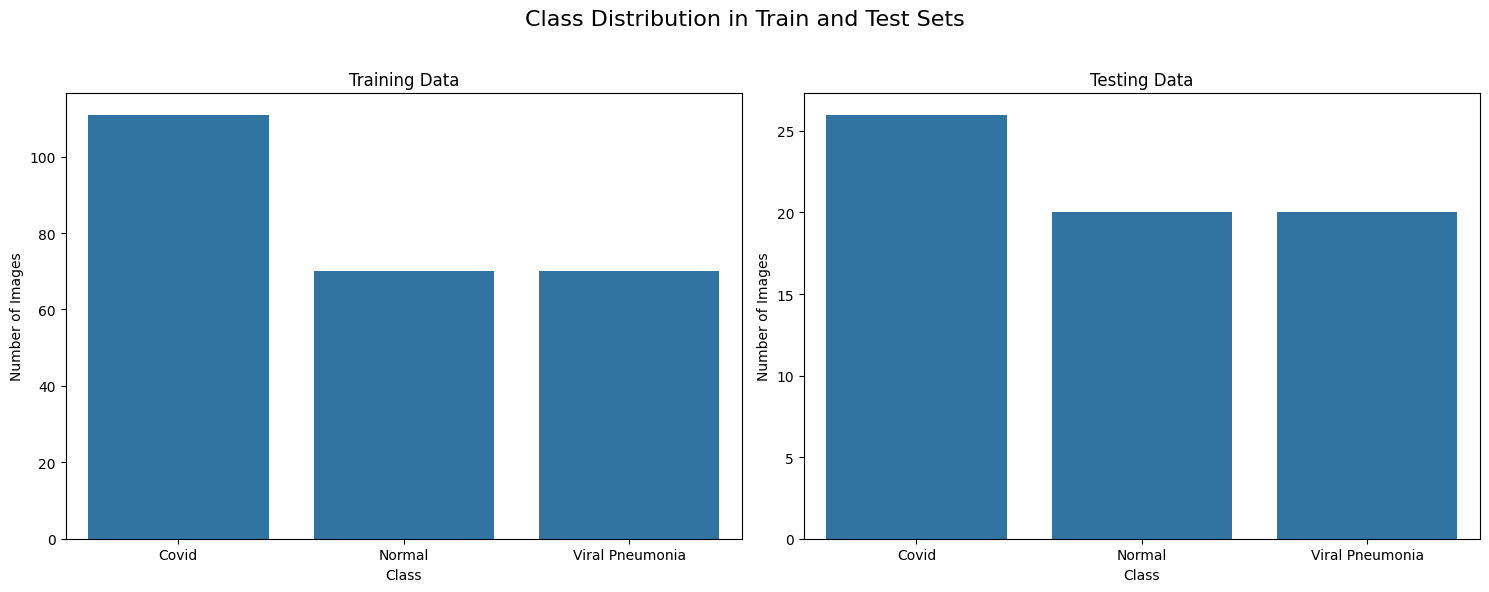

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the base directory where the 'Covid19-dataset' is located
# Make sure to adjust this path if your notebook is in a different location
base_dir = 'Covid19-dataset'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

# Define the categories
categories = ['Covid', 'Normal', 'Viral Pneumonia']

# --- Count files in the training directory ---
train_counts = {}
print("--- Training Data Distribution ---")
for category in categories:
    folder_path = os.path.join(train_dir, category)
    # Count the number of files in the directory
    num_files = len(os.listdir(folder_path))
    train_counts[category] = num_files
    print(f"Class '{category}': {num_files} images")

print("\n" + "="*35 + "\n")

# --- Count files in the testing directory ---
test_counts = {}
print("--- Testing Data Distribution ---")
for category in categories:
    folder_path = os.path.join(test_dir, category)
    # Count the number of files in the directory
    num_files = len(os.listdir(folder_path))
    test_counts[category] = num_files
    print(f"Class '{category}': {num_files} images")

# --- Visualize the distributions ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Class Distribution in Train and Test Sets', fontsize=16)

# Plot for training data
sns.barplot(ax=axes[0], x=list(train_counts.keys()), y=list(train_counts.values()))
axes[0].set_title('Training Data')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Images')

# Plot for testing data
sns.barplot(ax=axes[1], x=list(test_counts.keys()), y=list(test_counts.values()))
axes[1].set_title('Testing Data')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Number of Images')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- Define Constants ---
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32

# --- Create an Augmented Data Generator for Training ---
# We add several random transformations to our training data.
print("Creating the training data generator with augmentation...")
train_datagen = ImageDataGenerator(
    rescale=1./255,             # Normalize pixel values to [0, 1]
    rotation_range=20,          # Randomly rotate images by up to 20 degrees
    width_shift_range=0.2,      # Randomly shift images horizontally
    height_shift_range=0.2,     # Randomly shift images vertically
    shear_range=0.2,            # Apply shear transformations
    zoom_range=0.2,             # Randomly zoom in on images
    horizontal_flip=True,       # Randomly flip images horizontally
    fill_mode='nearest'         # Strategy for filling in newly created pixels
)

# --- Create a Non-Augmented Data Generator for Testing ---
# For the test data, we only need to normalize the pixel values. No augmentation!
print("Creating the testing data generator...")
test_datagen = ImageDataGenerator(rescale=1./255)

# --- Create the Actual Generators from Directories ---
# These generators will read images from the subfolders, apply the transformations,
# and feed them to the model in batches.

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical'  # For multi-class classification
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # It's good practice to not shuffle test data
)

# You can check the class indices that the generator assigned
print("\nClass Indices Assigned by the Generator:")
print(train_generator.class_indices)

Creating the training data generator with augmentation...
Creating the testing data generator...
Found 251 images belonging to 3 classes.
Found 66 images belonging to 3 classes.

Class Indices Assigned by the Generator:
{'Covid': 0, 'Normal': 1, 'Viral Pneumonia': 2}
